# Benchmark Analyis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('benchmark_results.csv', sep=';')
df.head()

,Execution_Number,Image_Name,Model,Time_to_Response_s,Model_Response
0,1,"1,jpg",Ollama-Gemma3-4B,"1,1003",What is the color of the truck in the image?: ...
1,2,"1,jpg",Ollama-Gemma3-4B,"0,6831",What is the color of the truck in the image?: ...
2,3,"1,jpg",Ollama-Gemma3-4B,"0,7630",What is the color of the truck in the image?: ...
3,4,"1,jpg",Ollama-Gemma3-4B,"0,7188",What is the color of the truck in the image?: ...
4,5,"1,jpg",Ollama-Gemma3-4B,"0,7175",What is the color of the truck in the image?: ...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Execution_Number    600 non-null    int64 
 1   Image_Name          600 non-null    object
 2   Model               600 non-null    object
 3   Time_to_Response_s  600 non-null    object
 4   Model_Response      600 non-null    object
dtypes: int64(1), object(4)
memory usage: 23.6+ KB


In [4]:
df['Time_to_Response_s_correct'] = df['Time_to_Response_s'].str.replace(',','.', regex=True)

In [5]:
df['Time_to_Response_s'] = df['Time_to_Response_s_correct'].astype(np.float64)

In [6]:
df.drop(columns=['Time_to_Response_s_correct'], inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Execution_Number    600 non-null    int64  
 1   Image_Name          600 non-null    object 
 2   Model               600 non-null    object 
 3   Time_to_Response_s  600 non-null    float64
 4   Model_Response      600 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 23.6+ KB


In [8]:
df['Model'].unique()

array(['Ollama-Gemma3-4B', 'Ollama-Moondream', 'BLIP-VQA'], dtype=object)

## Box Plots

In [9]:
df_filtered = df[df['Model'] == 'BLIP-VQA']

In [10]:
df_filtered.describe()

,Execution_Number,Time_to_Response_s
count,200.000000,200.000000
mean,500.500000,0.094485
std,57.879185,0.007863
min,401.000000,0.089300
25%,450.750000,0.091700
50%,500.500000,0.092100
75%,550.250000,0.092725
max,600.000000,0.128900


In [11]:
def box_model_time(df: pd.DataFrame, model_name: str ='BLIP-VQA' ):
    df_filtered = df[df['Model'] == model_name]
    fig, ax = plt.subplots(figsize=(30,10))
    ax.set_ylim(0,1.1)
    sns.boxplot(data=df_filtered, x='Image_Name', y='Time_to_Response_s')
    plt.show()

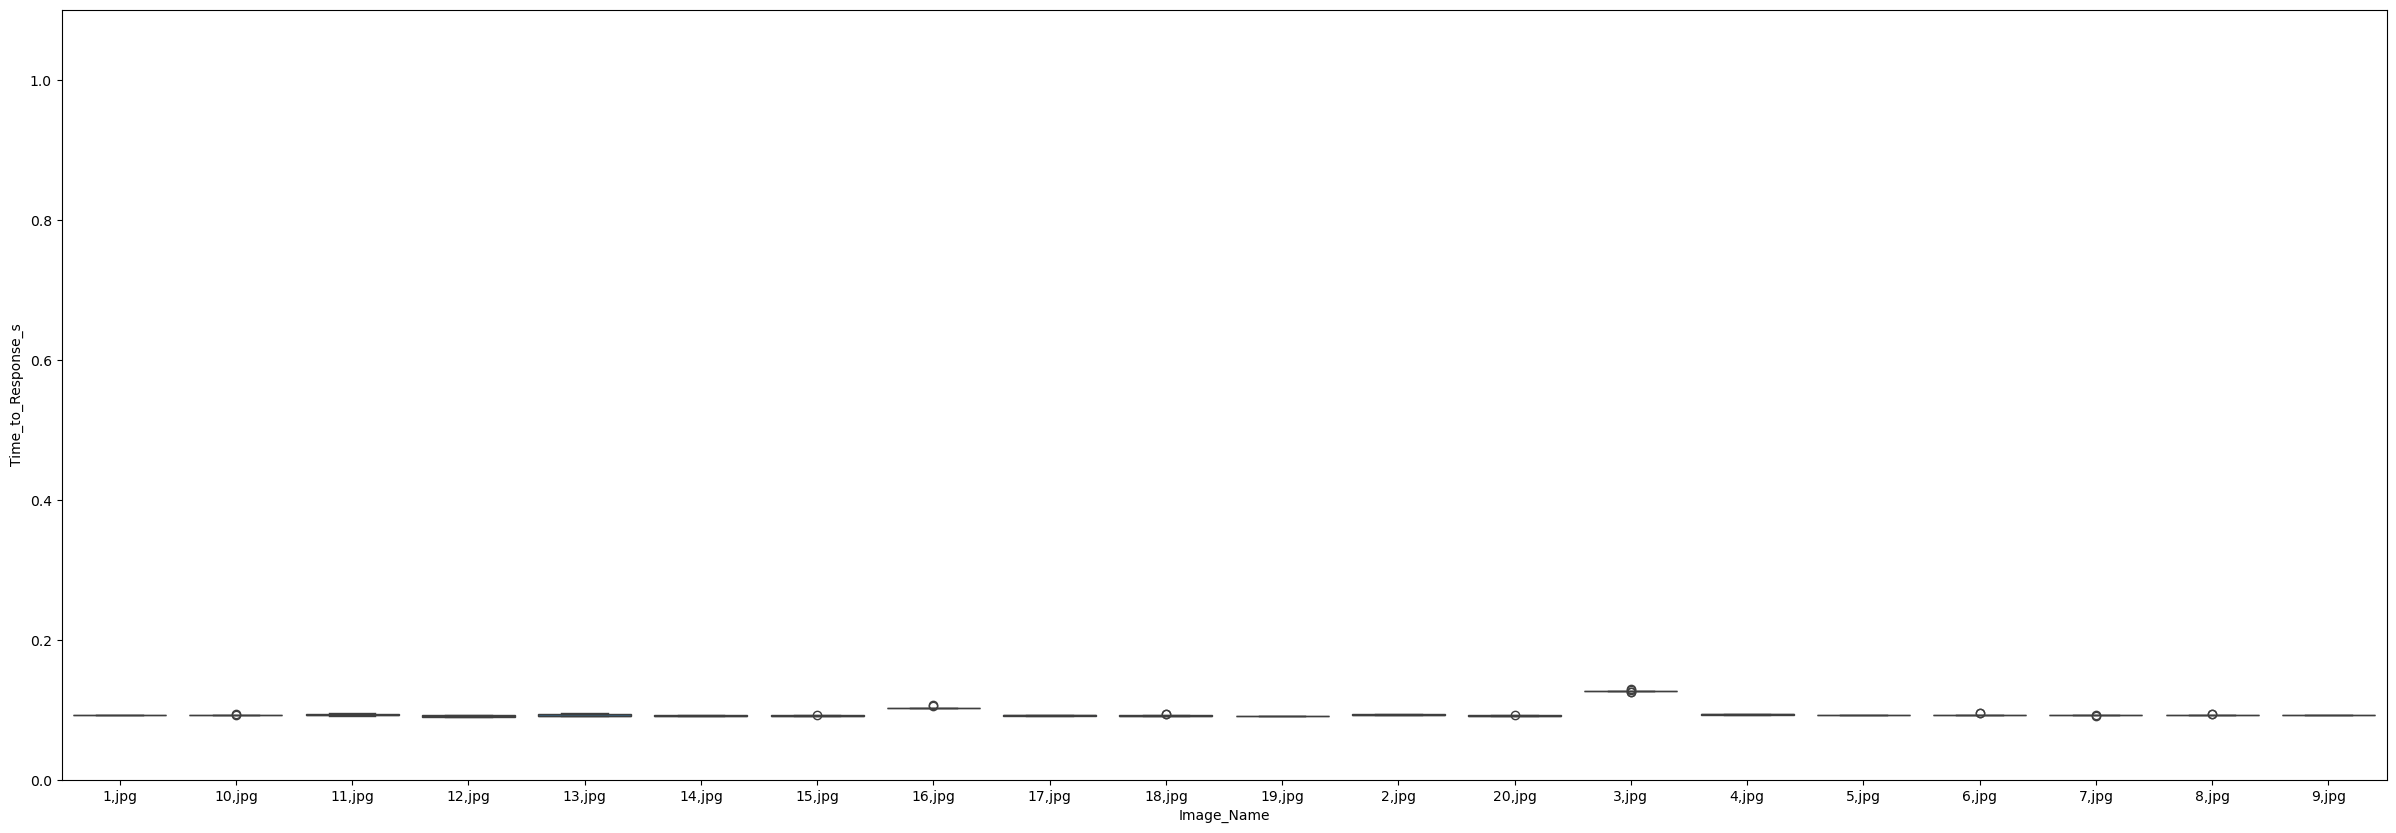

In [12]:
# Blip-VQA box plot
box_model_time(df, 'BLIP-VQA')

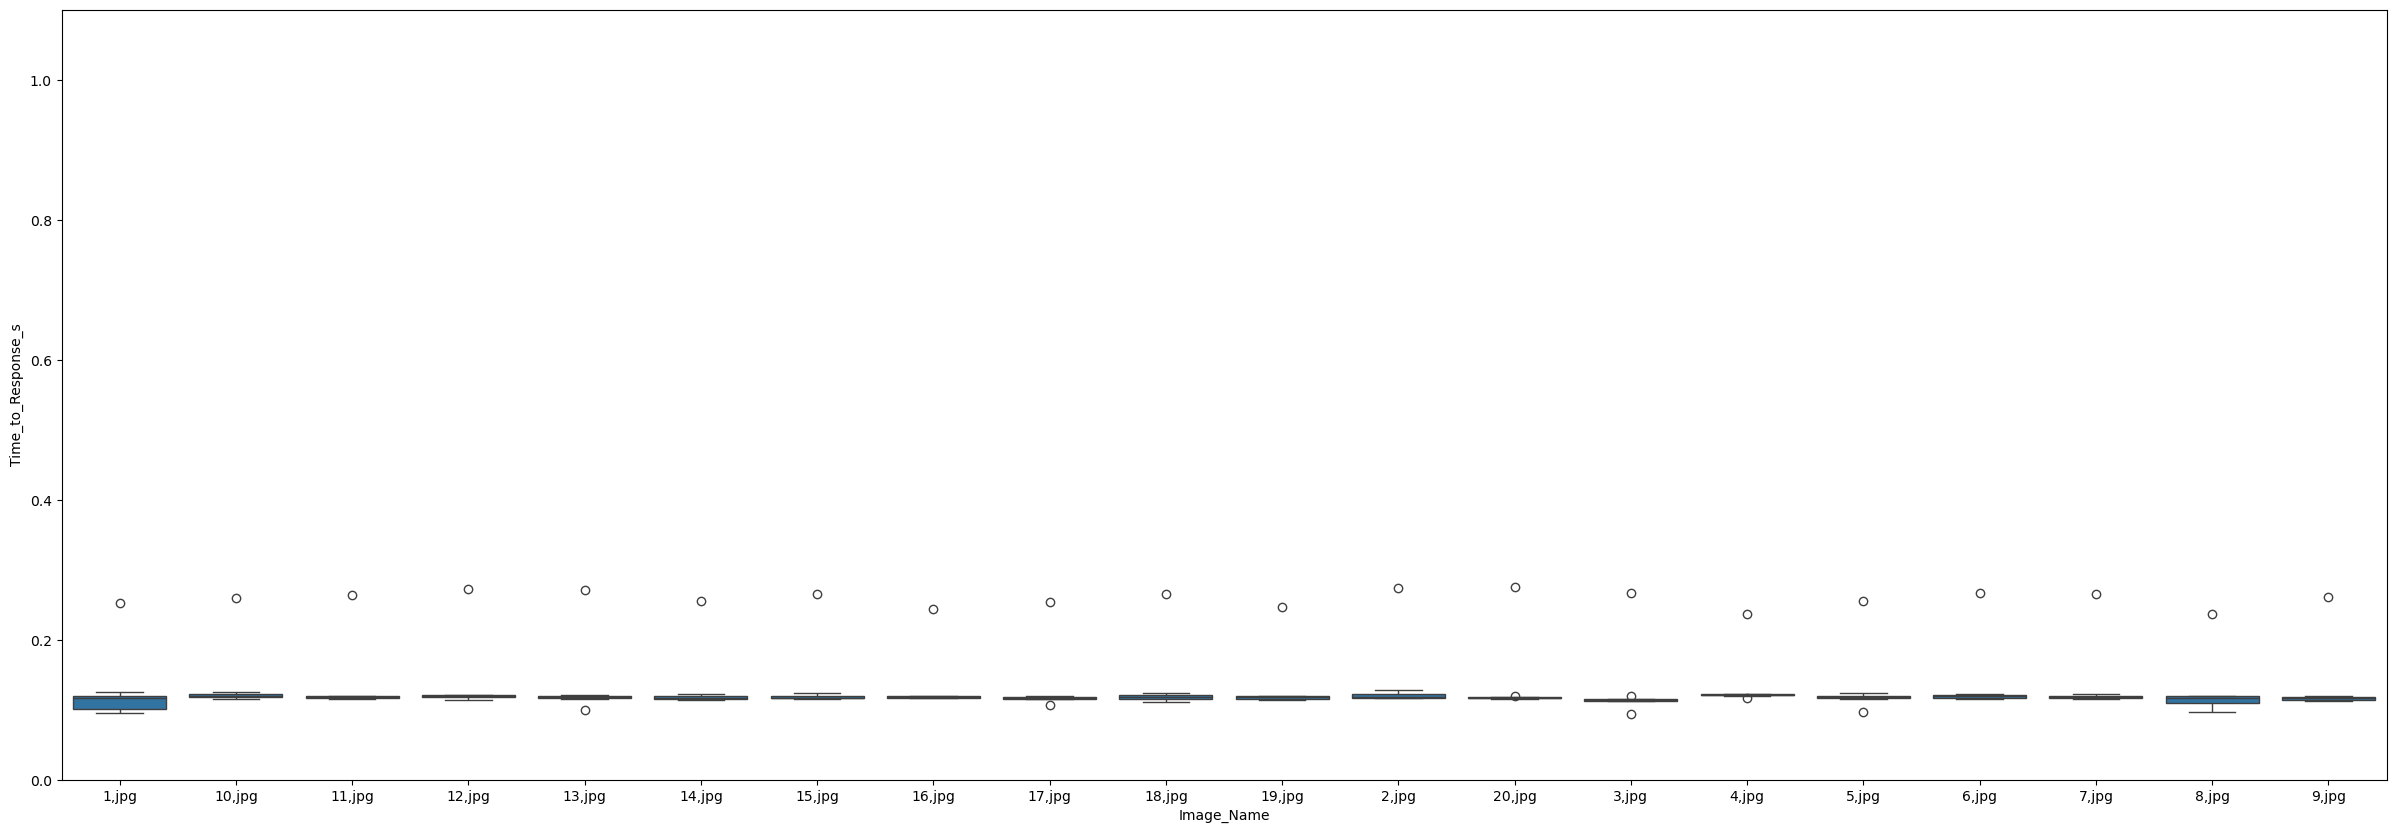

In [13]:
box_model_time(df, 'Ollama-Moondream')

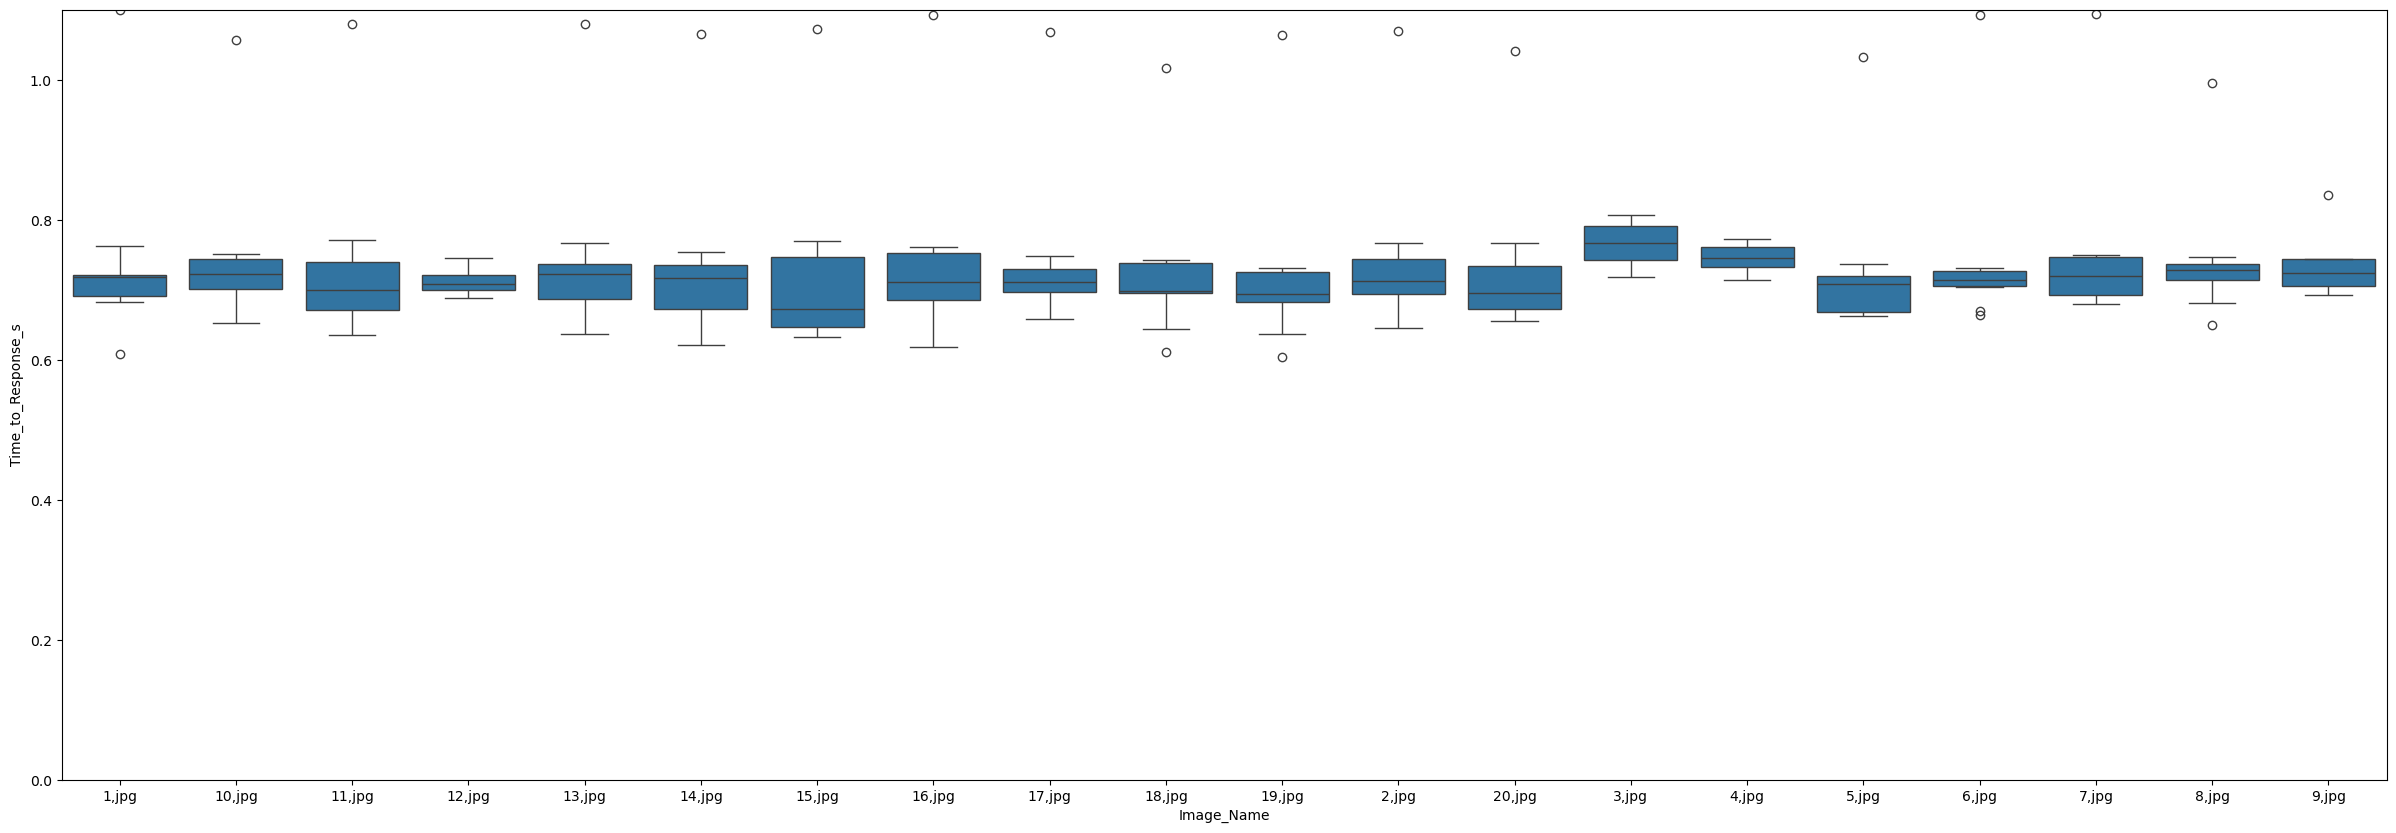

In [14]:
box_model_time(df, 'Ollama-Gemma3-4B')

In [16]:
df['QA_Pairs'] = df['Model_Response'].str.split('|')

In [17]:
df_exploded = df.explode('QA_Pairs', ignore_index=True)

In [44]:
df_gt = pd.read_csv('ground_truths.csv', sep=';')
df_gt.head()

,Image_Name,Question,Answer
0,"1,jpg",What is the color of the truck in the image?,white
1,"1,jpg",What is the type of the truck that is shown in...,van|delivery
2,"2,jpg",What is the color of the car in the image?,white
3,"2,jpg",What is the type of the car that is shown in t...,hatch
4,"3,jpg",What is the color of the bus in the image?,yellow


In [18]:
df_exploded.head()

,Execution_Number,Image_Name,Model,Time_to_Response_s,Model_Response,QA_Pairs
0,1,"1,jpg",Ollama-Gemma3-4B,1.1003,What is the color of the truck in the image?: ...,What is the color of the truck in the image?: ...
1,1,"1,jpg",Ollama-Gemma3-4B,1.1003,What is the color of the truck in the image?: ...,What is the type of the truck that is shown i...
2,2,"1,jpg",Ollama-Gemma3-4B,0.6831,What is the color of the truck in the image?: ...,What is the color of the truck in the image?: ...
3,2,"1,jpg",Ollama-Gemma3-4B,0.6831,What is the color of the truck in the image?: ...,What is the type of the truck that is shown i...
4,3,"1,jpg",Ollama-Gemma3-4B,0.7630,What is the color of the truck in the image?: ...,What is the color of the truck in the image?: ...


In [19]:
df_exploded[['Question','Model_Answer']] = df_exploded['QA_Pairs'].str.split(':',n=1,expand=True)

In [20]:
df_strucutured = df_exploded.drop(columns=['Model_Response','QA_Pairs'])

In [21]:
df_strucutured

,Execution_Number,Image_Name,Model,Time_to_Response_s,Question,Model_Answer
0,1,"1,jpg",Ollama-Gemma3-4B,1.1003,What is the color of the truck in the image?,White truck
1,1,"1,jpg",Ollama-Gemma3-4B,1.1003,What is the type of the truck that is shown i...,Van truck
2,2,"1,jpg",Ollama-Gemma3-4B,0.6831,What is the color of the truck in the image?,White truck
3,2,"1,jpg",Ollama-Gemma3-4B,0.6831,What is the type of the truck that is shown i...,Van truck
4,3,"1,jpg",Ollama-Gemma3-4B,0.7630,What is the color of the truck in the image?,White truck
...,...,...,...,...,...,...
1195,598,"9,jpg",BLIP-VQA,0.0922,What is the type of the car that is shown in ...,audi
1196,599,"9,jpg",BLIP-VQA,0.0920,What is the color of the car in the image?,silver car
1197,599,"9,jpg",BLIP-VQA,0.0920,What is the type of the car that is shown in ...,audi
1198,600,"9,jpg",BLIP-VQA,0.0922,What is the color of the car in the image?,silver car


In [64]:
df_gt['Answer'] = df_gt['Answer'].str.split('|')

In [72]:
benchmark_df = pd.read_csv('benchmark_results.csv', delimiter=';')
ground_truths_df = pd.read_csv('ground_truths.csv', delimiter=';')

# Display head to confirm structure and column names
print("Benchmark Results Head:")
print(benchmark_df.head())
print("\nGround Truths Head:")
print(ground_truths_df.head())

# Check info to see data types (especially for handling potential float conversions if needed, though strings are primary here)
print("\nBenchmark Info:")
print(benchmark_df.info())
print("\nGround Truths Info:")
print(ground_truths_df.info())
def check_substring(model_answer, ground_truth_alternatives):
    """
    Checks if any of the ground truth alternatives is a substring of the model's answer.
    
    Args:
        model_answer (str): The response string from the model.
        ground_truth_alternatives (str): Ground truth answers separated by '|'.
        
    Returns:
        bool: True if a match is found, False otherwise.
    """
    if not isinstance(model_answer, str) or not isinstance(ground_truth_alternatives, str):
        return False
        
    # Normalize model answer
    model_answer_norm = model_answer.lower()
    
    # Split alternatives and normalize
    alternatives = [alt.strip().lower() for alt in ground_truth_alternatives.split('|')]
    
    for alt in alternatives:
        if alt in model_answer_norm:
            return True
            
    return False

# Apply the evaluation
results = []

for idx, row in benchmark_df.iterrows():
    image_name = row['Image_Name']
    model_response = row['Model_Response']
    model_name = row['Model']
    
    # Get relevant ground truths for this image
    relevant_gts = ground_truths_df[ground_truths_df['Image_Name'] == image_name]
    
    for _, gt_row in relevant_gts.iterrows():
        ground_truth_answer = gt_row['Answer']
        question = gt_row['Question']
        
        is_correct = check_substring(model_response, ground_truth_answer)
        
        results.append({
            'Model': model_name,
            'Image': image_name,
            'Question': question,
            'Is_Correct': is_correct
        })

results_df = pd.DataFrame(results)

# Calculate accuracy per model
model_accuracy = results_df.groupby('Model')['Is_Correct'].mean().reset_index()
model_accuracy.columns = ['Model', 'Accuracy']
model_accuracy['Accuracy_Percent'] = model_accuracy['Accuracy'] * 100

print(model_accuracy)

Benchmark Results Head:
   Execution_Number Image_Name             Model Time_to_Response_s  \
0                 1      1,jpg  Ollama-Gemma3-4B             1,1003   
1                 2      1,jpg  Ollama-Gemma3-4B             0,6831   
2                 3      1,jpg  Ollama-Gemma3-4B             0,7630   
3                 4      1,jpg  Ollama-Gemma3-4B             0,7188   
4                 5      1,jpg  Ollama-Gemma3-4B             0,7175   

                                      Model_Response  
0  What is the color of the truck in the image?: ...  
1  What is the color of the truck in the image?: ...  
2  What is the color of the truck in the image?: ...  
3  What is the color of the truck in the image?: ...  
4  What is the color of the truck in the image?: ...  

Ground Truths Head:
  Image_Name                                           Question        Answer
0      1,jpg       What is the color of the truck in the image?         white
1      1,jpg  What is the type of the truc

/tmp/ipykernel_28150/1545576654.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy_Percent', data=model_accuracy, palette='viridis')


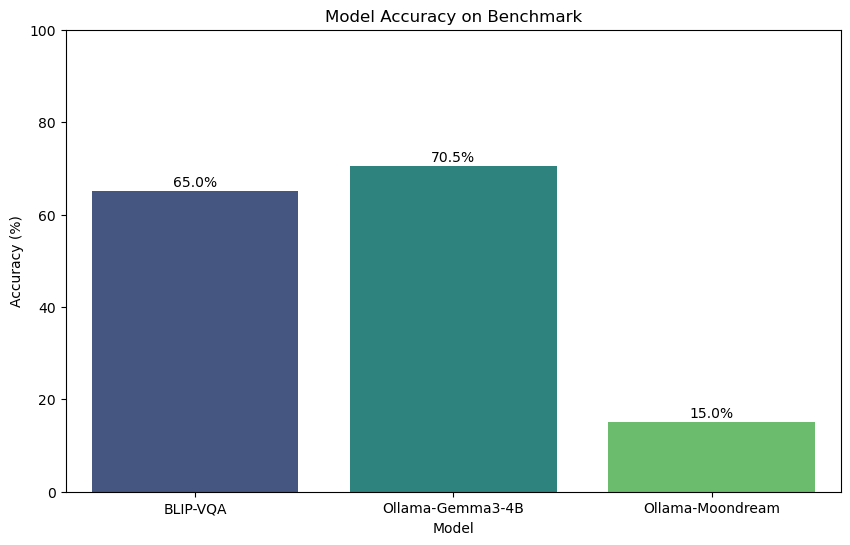

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy_Percent', data=model_accuracy, palette='viridis')
plt.title('Model Accuracy on Benchmark')
plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
plt.ylim(0, 100)
for index, row in model_accuracy.iterrows():
    plt.text(index, row.Accuracy_Percent + 1, f"{row.Accuracy_Percent:.1f}%", color='black', ha="center")

plt.savefig('model_accuracy_chart.png')

/tmp/ipykernel_28150/1182292445.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=benchmark_df, x='Model', y='Time_to_Response_s', palette='Set2')


Analysis complete. Plots generated.
              Model  Avg_Accuracy  Avg_Time  Time_Std  Avg_Color_Accuracy  \
0          BLIP-VQA         0.650  0.094484  0.007863                0.80   
1  Ollama-Gemma3-4B         0.705  0.745267  0.116626                0.72   
2  Ollama-Moondream         0.150  0.131160  0.043288                0.00   

   Avg_Type_Accuracy  
0               0.50  
1               0.69  
2               0.30  


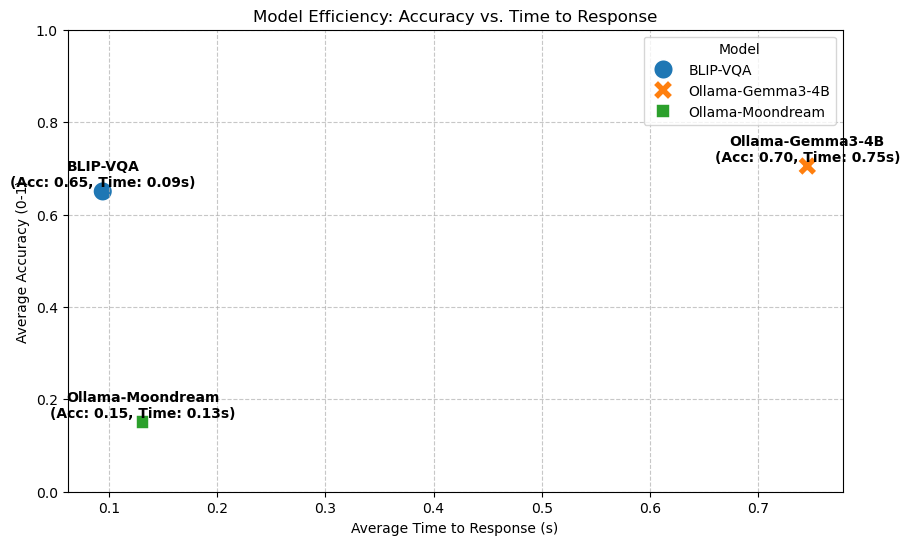

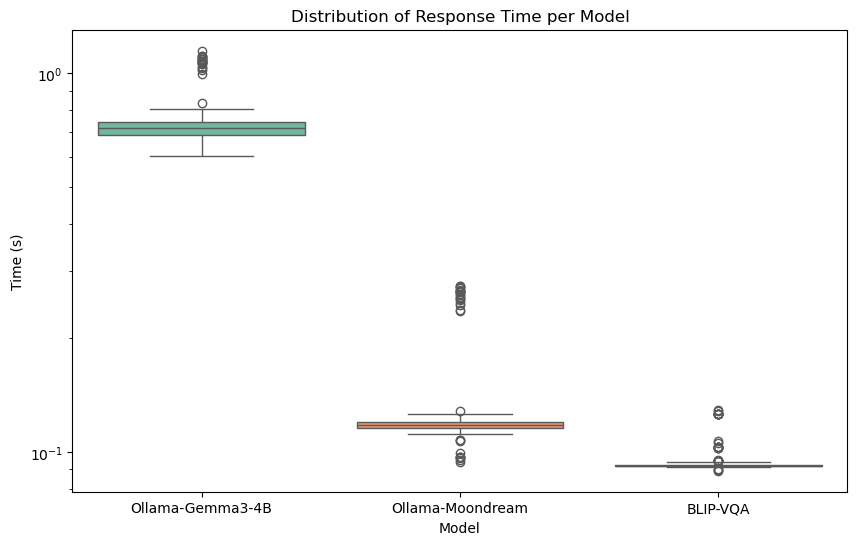

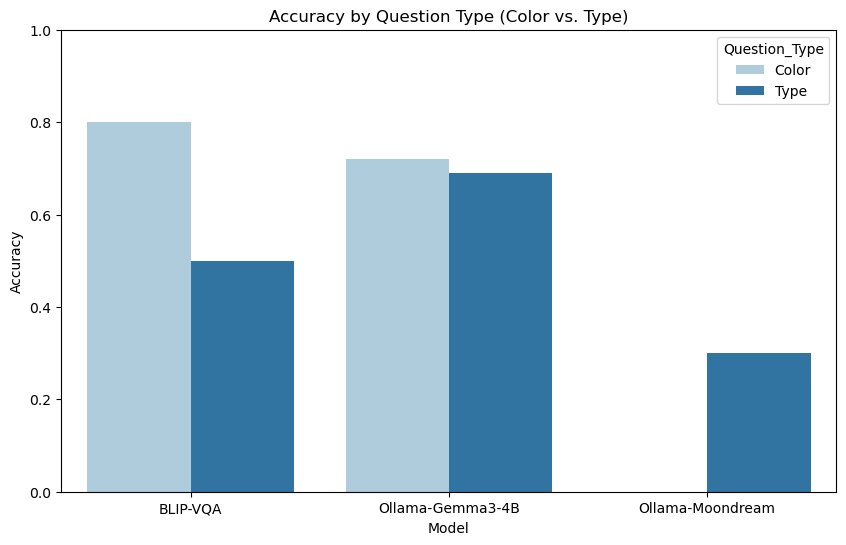

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the datasets
benchmark_df = pd.read_csv('benchmark_results.csv', delimiter=';')
ground_truths_df = pd.read_csv('ground_truths.csv', delimiter=';')

# Clean Time_to_Response_s column
# It uses commas for decimals, we need to replace them with dots and convert to float
benchmark_df['Time_to_Response_s'] = benchmark_df['Time_to_Response_s'].astype(str).str.replace(',', '.').astype(float)

# Function to check correctness (re-implementing for this session)
def check_correctness(row, gt_df):
    image_name = row['Image_Name']
    model_response = row['Model_Response']
    
    # Find relevant ground truths for this image
    # Note: A single model response might contain answers to multiple questions if they are concatenated, 
    # or the benchmark might have one row per question. 
    # Looking at the previous output: "What is the color...?: White truck | What is the type...?: Van truck"
    # It seems the model response contains answers to *all* questions for that image.
    # And the ground truth has separate rows for each question for that image.
    
    relevant_gts = gt_df[gt_df['Image_Name'] == image_name]
    
    if relevant_gts.empty:
        return 0 # Should not happen based on previous inspection
        
    correct_count = 0
    total_questions = len(relevant_gts)
    
    for _, gt_row in relevant_gts.iterrows():
        gt_alternatives = gt_row['Answer'].split('|')
        # Check if ANY of the alternatives is in the model response
        # We need to be careful. If the question is "color", we don't want to match "white" from the "type" answer if the color was "red".
        # However, the previous prompt's logic was just "substring check". 
        # To be more robust, ideally we split the model response, but the simple substring check was requested.
        # Let's stick to the simple substring check as requested previously, but maybe refine it if "other analysis" implies better analysis.
        # For now, let's stick to the global substring check per image-row.
        
        found = False
        for alt in gt_alternatives:
            if alt.strip().lower() in model_response.lower():
                found = True
                break
        if found:
            correct_count += 1
            
    # Return the proportion of correct answers for this image
    return correct_count / total_questions if total_questions > 0 else 0

# Apply correctness check
# Note: The benchmark_df has multiple executions per image.
benchmark_df['Accuracy_Score'] = benchmark_df.apply(lambda row: check_correctness(row, ground_truths_df), axis=1)

# Categorize questions to add "Type of Analysis"
# We need to merge question info back to benchmark to analyze by question type? 
# The benchmark row has the full response. It doesn't split by question. 
# So we can't easily say "this row is a Color question". 
# However, we can calculate accuracy specifically for "Color" questions and "Type" questions separately.

def get_specific_accuracy(row, gt_df, question_keyword):
    image_name = row['Image_Name']
    model_response = row['Model_Response']
    relevant_gts = gt_df[gt_df['Image_Name'] == image_name]
    
    target_gts = relevant_gts[relevant_gts['Question'].str.contains(question_keyword, case=False)]
    
    if target_gts.empty:
        return np.nan # No question of this type for this image
        
    correct_count = 0
    for _, gt_row in target_gts.iterrows():
        gt_alternatives = gt_row['Answer'].split('|')
        found = False
        for alt in gt_alternatives:
            if alt.strip().lower() in model_response.lower():
                found = True
                break
        if found:
            correct_count += 1
            
    return correct_count / len(target_gts)

benchmark_df['Color_Accuracy'] = benchmark_df.apply(lambda row: get_specific_accuracy(row, ground_truths_df, 'color'), axis=1)
benchmark_df['Type_Accuracy'] = benchmark_df.apply(lambda row: get_specific_accuracy(row, ground_truths_df, 'type'), axis=1)

# Aggregations
model_stats = benchmark_df.groupby('Model').agg({
    'Accuracy_Score': 'mean',
    'Time_to_Response_s': ['mean', 'std'],
    'Color_Accuracy': 'mean',
    'Type_Accuracy': 'mean'
}).reset_index()

# Flatten columns
model_stats.columns = ['Model', 'Avg_Accuracy', 'Avg_Time', 'Time_Std', 'Avg_Color_Accuracy', 'Avg_Type_Accuracy']

# --- Plots ---

# 1. Efficiency Plot (Scatter: Time vs Accuracy)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=model_stats, x='Avg_Time', y='Avg_Accuracy', s=200, hue='Model', style='Model')

# Add labels
for i, row in model_stats.iterrows():
    plt.text(row['Avg_Time'], row['Avg_Accuracy'] + 0.01, 
             f"{row['Model']}\n(Acc: {row['Avg_Accuracy']:.2f}, Time: {row['Avg_Time']:.2f}s)", 
             horizontalalignment='center', size='medium', color='black', weight='semibold')

plt.title('Model Efficiency: Accuracy vs. Time to Response')
plt.xlabel('Average Time to Response (s)')
plt.ylabel('Average Accuracy (0-1)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 1.0) # Accuracy is 0 to 1
plt.savefig('efficiency_plot.png')

# 2. Time Distribution (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=benchmark_df, x='Model', y='Time_to_Response_s', palette='Set2')
plt.title('Distribution of Response Time per Model')
plt.ylabel('Time (s)')
plt.yscale('log') # Using log scale if there are large differences, let's check linear first or just use linear if plausible. 
# The snippet showed times like 0.7s, 1.1s. It's likely fine on linear. 
# Let's stick to linear for now.
plt.savefig('time_distribution_plot.png')

# 3. Accuracy Breakdown (Bar Plot)
# Melt for plotting
accuracy_melted = model_stats.melt(id_vars='Model', value_vars=['Avg_Color_Accuracy', 'Avg_Type_Accuracy'], 
                                   var_name='Question_Type', value_name='Accuracy')
accuracy_melted['Question_Type'] = accuracy_melted['Question_Type'].str.replace('Avg_', '').str.replace('_Accuracy', '')

plt.figure(figsize=(10, 6))
sns.barplot(data=accuracy_melted, x='Model', y='Accuracy', hue='Question_Type', palette='Paired')
plt.title('Accuracy by Question Type (Color vs. Type)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.savefig('accuracy_breakdown.png')

print("Analysis complete. Plots generated.")
print(model_stats)

Unique Image IDs: [ 1 10 11 12 13 14 15 16 17 18 19  2 20  3  4  5  6  7  8  9]
              Model  Size_Category  Accuracy_Score  Time_to_Response_s
0          BLIP-VQA     Big (1-10)            0.80            0.095942
1          BLIP-VQA  Small (11-20)            0.50            0.093027
2  Ollama-Gemma3-4B     Big (1-10)            0.83            0.755057
3  Ollama-Gemma3-4B  Small (11-20)            0.58            0.735476
4  Ollama-Moondream     Big (1-10)            0.10            0.130677
5  Ollama-Moondream  Small (11-20)            0.20            0.131643


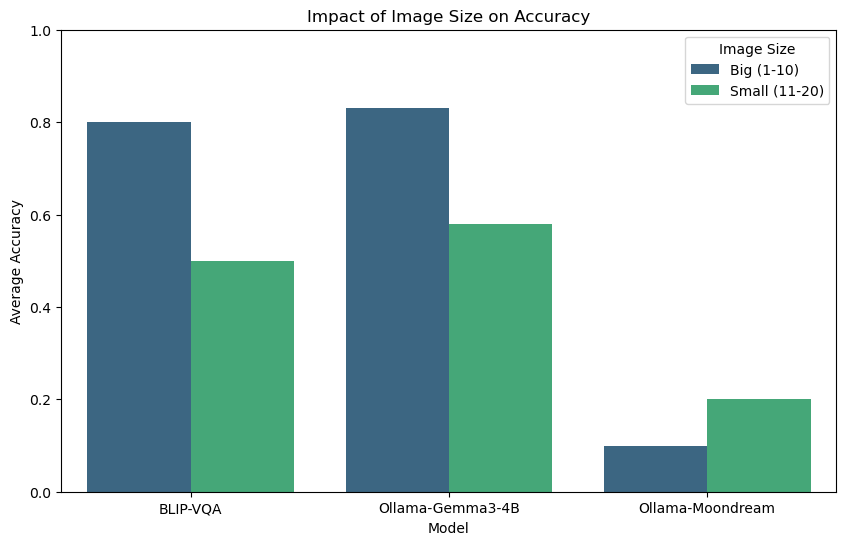

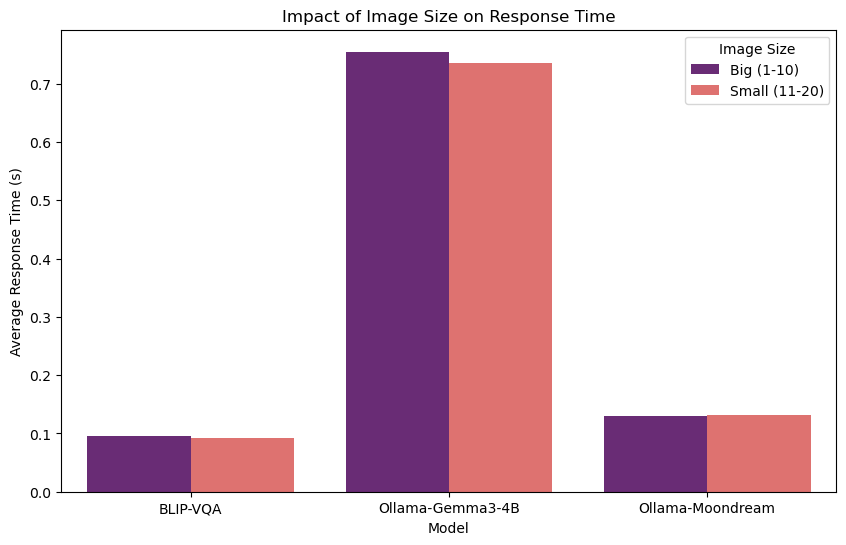

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the datasets
benchmark_df = pd.read_csv('benchmark_results.csv', delimiter=';')
ground_truths_df = pd.read_csv('ground_truths.csv', delimiter=';')

# Clean Time_to_Response_s column
benchmark_df['Time_to_Response_s'] = benchmark_df['Time_to_Response_s'].astype(str).str.replace(',', '.').astype(float)

# Function to extract image ID
def get_image_id(image_name):
    # Image name format is "X,jpg"
    try:
        return int(image_name.split(',')[0])
    except:
        return -1

benchmark_df['Image_ID'] = benchmark_df['Image_Name'].apply(get_image_id)

# Create Size Category
def categorize_size(img_id):
    if 1 <= img_id <= 10:
        return 'Big (1-10)'
    elif 11 <= img_id <= 20:
        return 'Small (11-20)'
    else:
        return 'Other'

benchmark_df['Size_Category'] = benchmark_df['Image_ID'].apply(categorize_size)

# Filter out 'Other' if any (though based on previous info, there are 20 images usually? Ground truth has 40 rows, 20 images * 2 questions?)
# Let's check unique image IDs
print("Unique Image IDs:", benchmark_df['Image_ID'].unique())

# Re-implement accuracy check
def check_correctness(row, gt_df):
    image_name = row['Image_Name']
    model_response = row['Model_Response']
    relevant_gts = gt_df[gt_df['Image_Name'] == image_name]
    
    if relevant_gts.empty:
        return 0
        
    correct_count = 0
    total_questions = len(relevant_gts)
    
    for _, gt_row in relevant_gts.iterrows():
        gt_alternatives = gt_row['Answer'].split('|')
        found = False
        for alt in gt_alternatives:
            if alt.strip().lower() in model_response.lower():
                found = True
                break
        if found:
            correct_count += 1
            
    return correct_count / total_questions if total_questions > 0 else 0

benchmark_df['Accuracy_Score'] = benchmark_df.apply(lambda row: check_correctness(row, ground_truths_df), axis=1)

# Group by Model and Size_Category
# Filter to only keep Big and Small categories
analysis_df = benchmark_df[benchmark_df['Size_Category'].isin(['Big (1-10)', 'Small (11-20)'])]

size_stats = analysis_df.groupby(['Model', 'Size_Category']).agg({
    'Accuracy_Score': 'mean',
    'Time_to_Response_s': 'mean'
}).reset_index()

print(size_stats)

# Plotting

# 1. Accuracy Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=size_stats, x='Model', y='Accuracy_Score', hue='Size_Category', palette='viridis')
plt.title('Impact of Image Size on Accuracy')
plt.ylabel('Average Accuracy')
plt.ylim(0, 1)
plt.legend(title='Image Size')
plt.savefig('size_accuracy_comparison.png')

# 2. Time Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=size_stats, x='Model', y='Time_to_Response_s', hue='Size_Category', palette='magma')
plt.title('Impact of Image Size on Response Time')
plt.ylabel('Average Response Time (s)')
plt.legend(title='Image Size')
plt.savefig('size_time_comparison.png')